In [2]:
import numpy as np;
import pandas as pd
import matplotlib.pyplot as plt;
from scipy.linalg import expm
from scipy.signal import find_peaks

# automatically updates and reloads the imported functions from my own modules
%load_ext autoreload
%autoreload 2

import mean_funcs
import toymodel_funcs
import Mpower_funcs
import Epower_funcs
import fourier_funcs

In [3]:
a=1
mu_list=np.array([-4])
t_list=np.linspace(0,500,10000)

## First Epower and Mpower of S, based on exact Hamiltonian ##

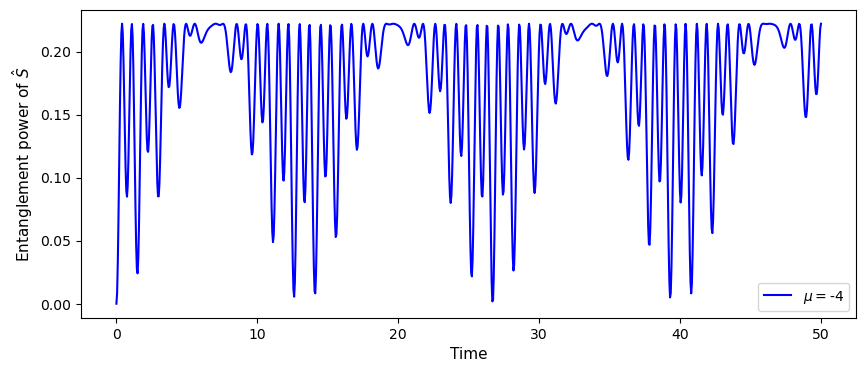

(1000,)


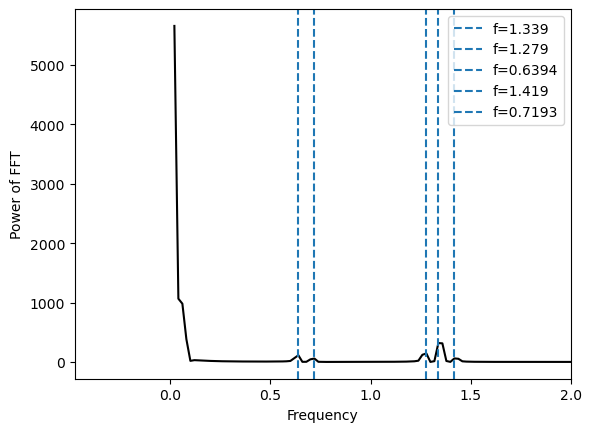

In [22]:
# Epower_funcs.Epower_S(a,mu_list,t_list,ylim,savetrue,savename,colourline)
entangle_list_mu = Epower_funcs.Epower_S(a,mu_list,t_list,None,False,'savename.png','b')
print(entangle_list_mu[0,:].shape)

# fourier_funcs.fourier(t_list,signal,xlim,numberpeaks), numberpeaks=-1 for all except last, or otherwise number of peaks
(freqpeak,powerpeak) = fourier_funcs.fourier(t_list,entangle_list_mu[0,:],(None,2),None,-1)

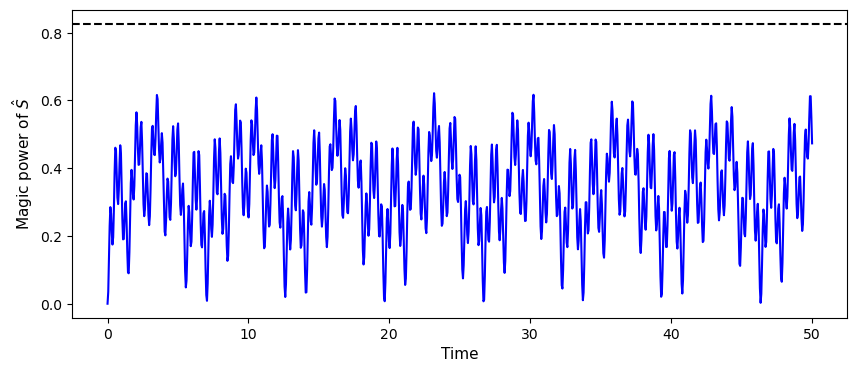

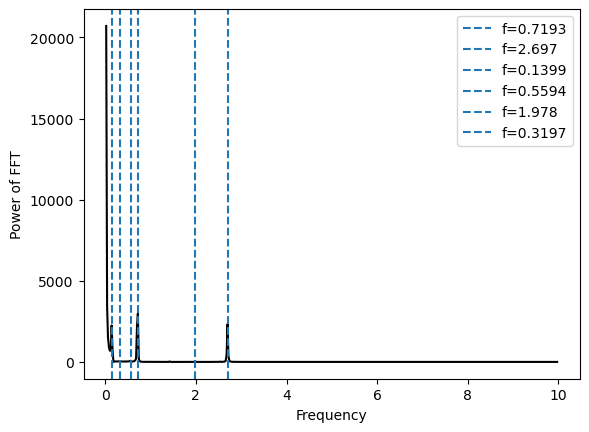

In [23]:
# Mpower_funcs.Mpower_S(a,mu_list,t_list,ylim,savetrue,savename,colourline)
magic_list_mu = Mpower_funcs.Mpower_S(a,mu_list,t_list,None,False,'savename.png','b')

# fourier_funcs.fourier(t_list,signal,xlim,numberpeaks), numberpeaks=-1 for all except last, or otherwise number of peaks
(freqpeak,powerpeak) = fourier_funcs.fourier(t_list,magic_list_mu[0,:],None,None,6)

## Now E and M of particular states, from EXACT SOLNS ##

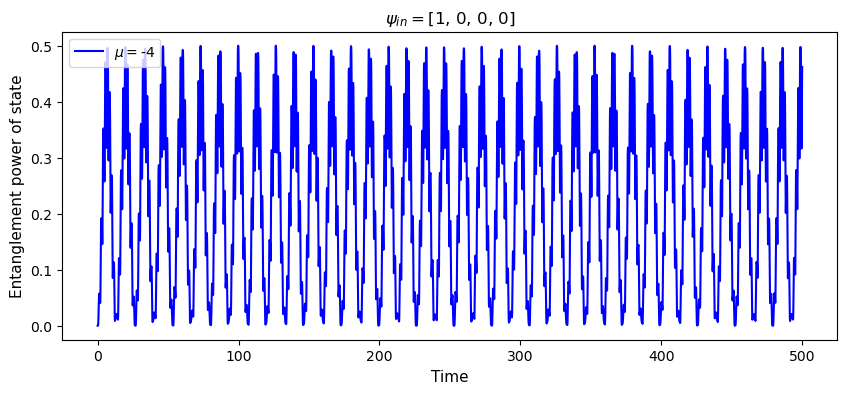

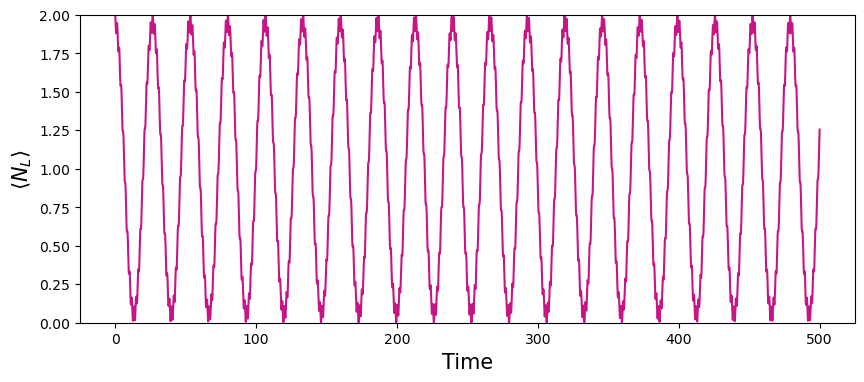

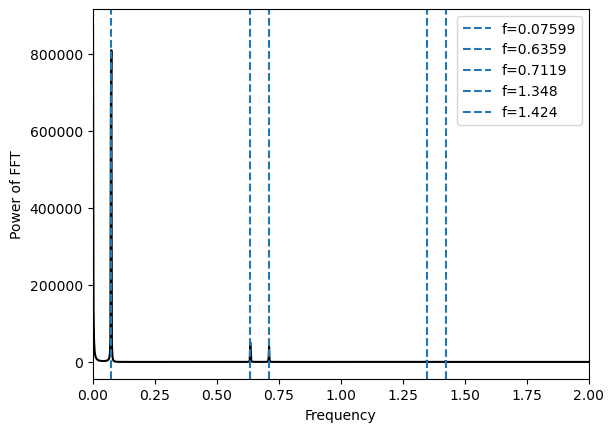

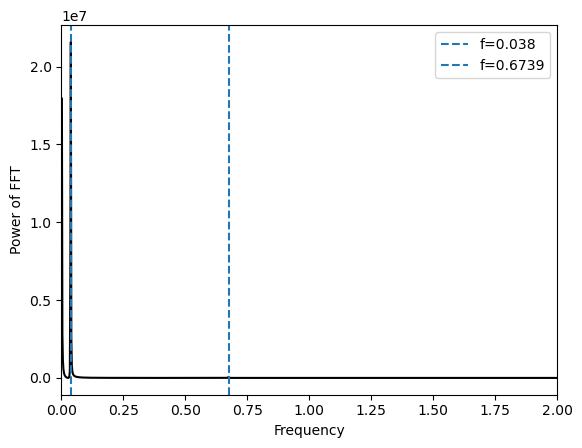

(array([0.0379962, 0.6739326]), array([21583316.70698309,    66789.36578572]))

In [30]:
# Epower_funcs.Epower_inout(a,mu_list,t_list,psi,ylim,savetrue,savename,colourline,mode="in")
psi = np.array([1,0,0,0]) # basis LL LR RL RR
entangle_list_mu = Epower_funcs.Epower_inout(a,mu_list,t_list,psi,None,False,'savename.png','b',mode="in")
# plt.plot(t_list,0.2*np.sin(t_list*2*np.pi*0.0376*2-np.pi/2)+0.2,'r')
plt.show()

exNL_mu = toymodel_funcs.N_L(a,mu_list,t_list,psi,False,'savename.png',mode="in")
# plt.plot(t_list,0.2*np.sin(t_list*2*np.pi*0.674+np.pi/2)+0.2,'r')
plt.show()


# fourier_funcs.fourier(t_list,signal,xlim,numberpeaks), numberpeaks=-1 for all except last, or otherwise number of peaks
(freqpeak,powerpeak) = fourier_funcs.fourier(t_list,entangle_list_mu[0,:],(0,2),None,5)

fourier_funcs.fourier(t_list,exNL_mu[0,:],(0,2),None,2)



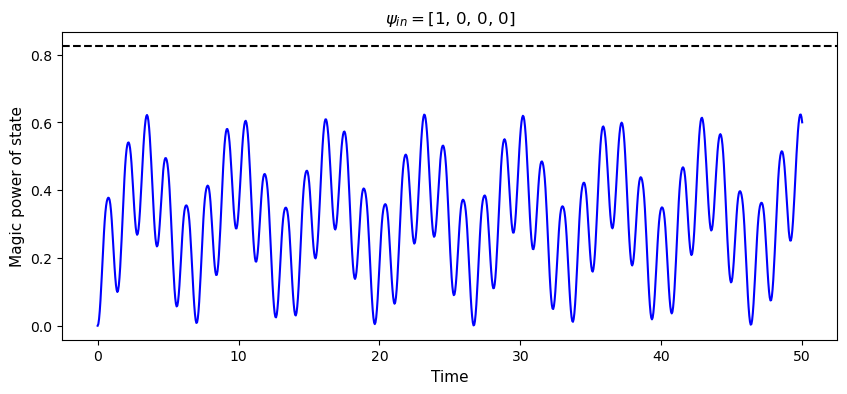

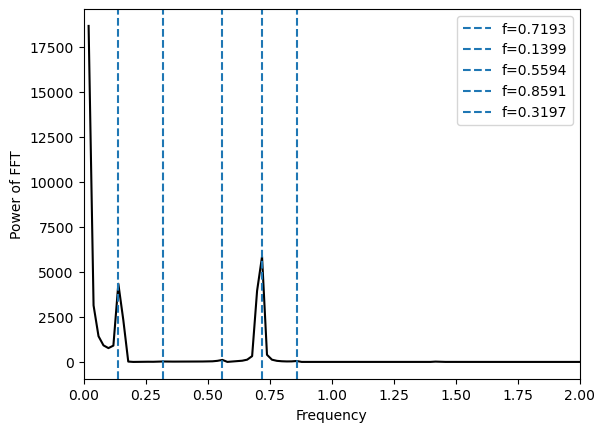

In [26]:
# Mpower_funcs.Mpower_inout(a,mu_list,t_list,psi,ylim,savetrue,savename,colourline,mode="in")
psi = np.array([1,0,0,0])
magic_list_mu = Mpower_funcs.Mpower_inout(a,mu_list,t_list,psi,None,False,'savename.png','b',mode="in")

# plt.figure(figsize=(10,4))
# plt.plot(t_list,0.2*np.sin(t_list*2*np.pi*0.862-np.pi/2)+0.3,'r')
plt.show()

# fourier_funcs.fourier(t_list,signal,xlim,numberpeaks), numberpeaks=-1 for all except last, or otherwise number of peaks
(freqpeak,powerpeak) = fourier_funcs.fourier(t_list,magic_list_mu[0,:],(0,2),None,5)

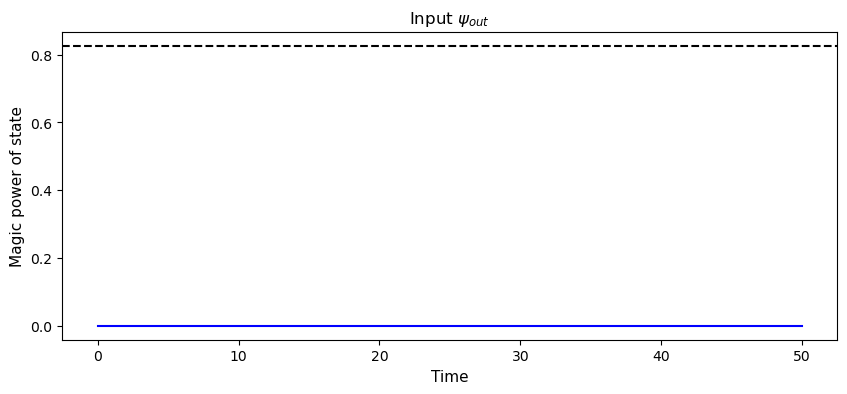

In [27]:
# Mpower_funcs.Mpower_inout(a,mu_list,t_list,psi,ylim,savetrue,savename,colourline,mode="in")
psi = np.array([np.sqrt(1/2),0,0,np.sqrt(1/2)])
magic_list_mu = Mpower_funcs.Mpower_inout(a,mu_list,t_list,psi,None,False,'savename.png','b',mode="out")

In [131]:
a=1
mu_list=np.array([4])
t_list=np.linspace(0,500,10000)

(1000, 4)


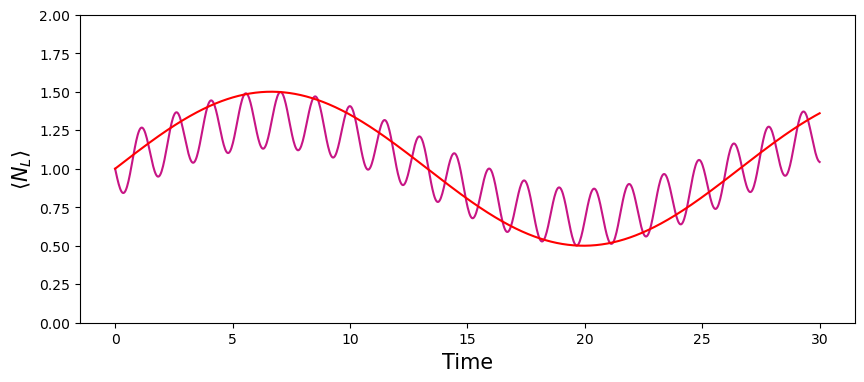

13.303303303303302


In [16]:
psi = 1/2*np.array([1,np.exp(1j*np.pi/4),np.exp(1j*np.pi/4),np.exp(1j*np.pi/2)])
psiout = []
for n, t in enumerate(t_list):
    S = np.array(toymodel_funcs.Evolve(a,mu_list[0],t))
    psiout.append(S @ psi)
psiout=np.array(psiout)
print(psiout.shape)

# plt.figure(figsize=(10,4))
# plt.plot(t_list, psiout[:,0].real, "-", label="LL")
# plt.plot(t_list, psiout[:,0].imag, "-", label="LL imag")
# plt.plot(t_list, psiout[:,3].real, "-", label="RR")
# plt.plot(t_list, psiout[:,3].imag, "-", label="RR imag")
# plt.legend()
# plt.show()

# plt.figure(figsize=(10,4))
# plt.plot(t_list, np.abs(psiout[:,0])**2, "-", label="LL")
# plt.plot(t_list, np.abs(psiout[:,3])**2, "-", label="RR")
# plt.plot(t_list, np.abs(psiout[:,1])**2, "-", label="LR")
# plt.plot(t_list, np.abs(psiout[:,2])**2, "-", label="RL")
# plt.legend()
# plt.ylim([0,1])
# plt.show()

exNL_mu = toymodel_funcs.N_L(a,mu_list,t_list,psi,False,'savename.png',mode="in")
plt.plot(t_list,0.5*np.sin(t_list*2*np.pi*0.0376)+1,'r')
plt.show()
timemin = t_list[ np.argmin(np.sin(t_list*2*np.pi*0.0376)) ] - t_list[ np.argmax(np.sin(t_list*2*np.pi*0.0376)) ]
print(timemin) # time where all particles tunnelled from LL to RR = 13.30 when started in magic state

# fourier_funcs.fourier(t_list,exNL_mu[0,:],(0,2),2)

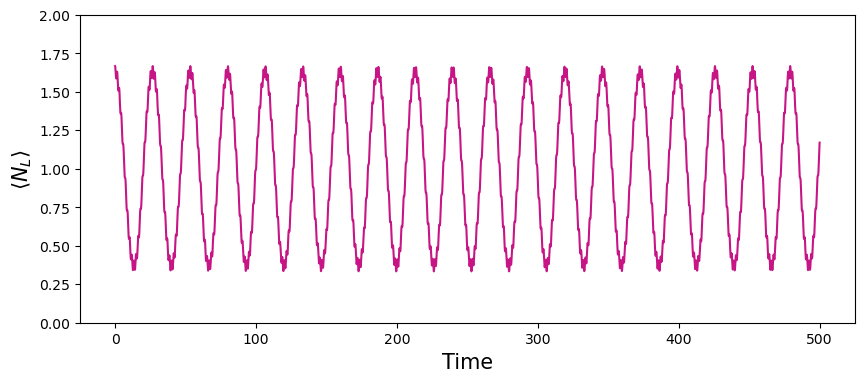

199.46994699469946


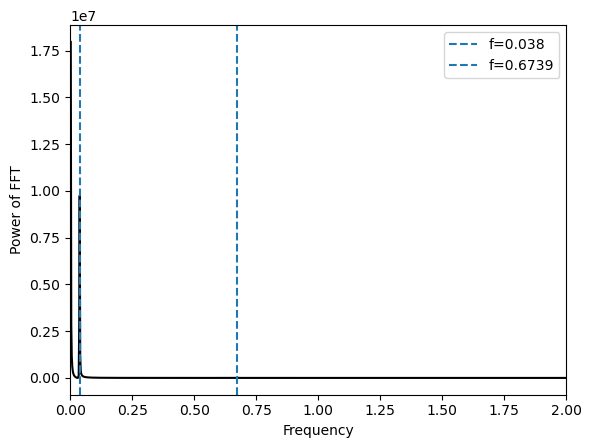

(array([0.0379962, 0.6739326]), array([9743714.44825166,   29624.73435672]))

In [135]:
psi = np.array([np.sqrt(5/6),0,0,np.sqrt(1/6)])
psiout = []
for n, t in enumerate(t_list):
    S = np.array(toymodel_funcs.Evolve(a,mu_list[0],t))
    psiout.append(S @ psi)
psiout=np.array(psiout)

exNL_mu = toymodel_funcs.N_L(a,mu_list,t_list,psi,False,'savename.png',mode="in")
# plt.plot(t_list,0.5*np.sin(t_list*2*np.pi*0.0376)+1,'r')
plt.show()
timemin = t_list[ np.argmin(np.sin(t_list*2*np.pi*0.0376)) ] - t_list[ np.argmax(np.sin(t_list*2*np.pi*0.0376)) ]
print(timemin) # time where all particles tunnelled from LL to RR = 13.30 when started in magic state

fourier_funcs.fourier(t_list,exNL_mu[0,:],(0,2),2)

## Mean field solns, check E and M powers plus N_L ##

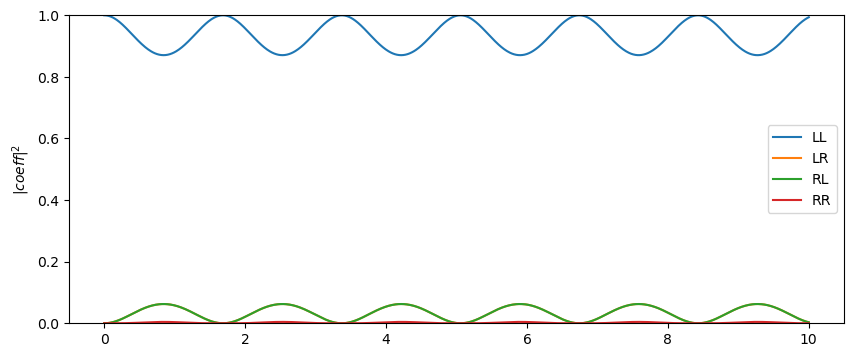

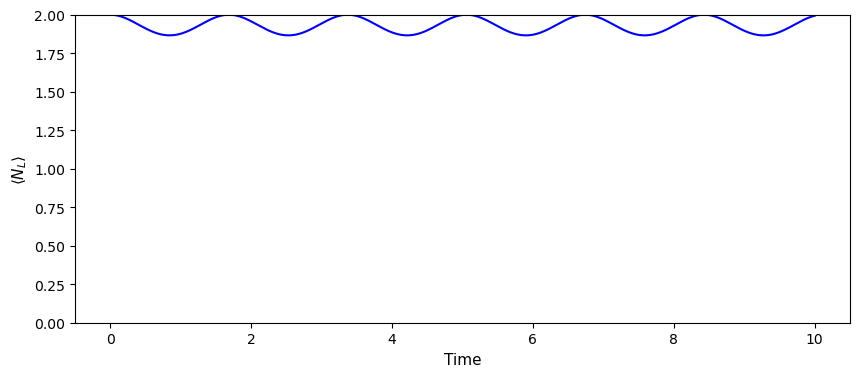

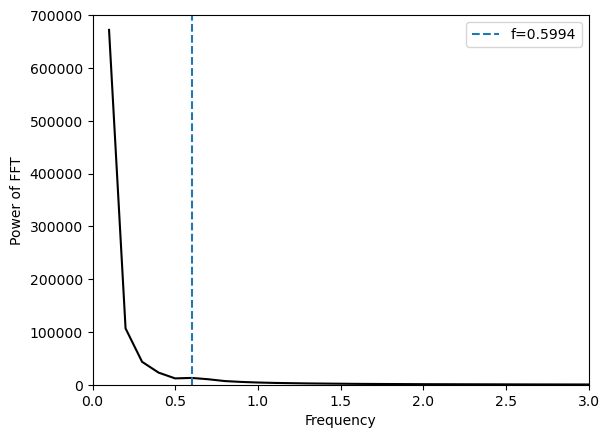

max power of a freq peak= 12878.795316804075


IndexError: index 1 is out of bounds for axis 0 with size 1

In [5]:
points=1000
t_list=np.linspace(0,10,points)
# intial state theta,phi :
U_0 = [np.pi/2 - 1e-5, 0] # this gives LL initially
# U_0 = [-np.arctan(np.sqrt(15))+np.pi,0] # this gives meanfield ground state FOR MU= 4
# U_0 = [np.arctan(np.sqrt(15)),0] # this gives meanfield ground state FOR MU= -4
# U_0 = [np.arcsin(2/3),np.pi/4] 

psi=mean_funcs.state(points, U_0, t_list, mu_list[0]) # basis LL LR RL RR
# print(psi.shape)
plt.figure(figsize=(10,4))
plt.plot(t_list, np.abs(psi[:,0])**2, "-", label="LL")
plt.plot(t_list, np.abs(psi[:,1])**2, "-", label="LR")
plt.plot(t_list, np.abs(psi[:,2])**2, "-", label="RL")
plt.plot(t_list, np.abs(psi[:,3])**2, "-", label="RR")
plt.ylabel(r'$|coeff|^2$')
plt.legend()
plt.ylim([0,1])
plt.show()


exNLmean=mean_funcs.N_L(points, U_0, t_list, mu_list[0])
# print(exNLmean.shape)

plt.figure(figsize=(10,4))
plt.plot(t_list,exNLmean,'b')
# plt.plot(t_list,1+0.4*np.sin(t_list*2*np.pi*0.207),'r')

plt.ylabel(fr'$\langle N_L \rangle$',fontsize=11)
plt.xlabel('Time',fontsize=11)
plt.ylim(0,2)
# plt.savefig(f'C:/Users/annas/Documents/2026/Honours/Entangle_Magic/mean_meanground_NL.png',bbox_inches='tight',dpi=300)
plt.show()

(freqpeak, powerpeak) = fourier_funcs.fourier(t_list,exNLmean,(0,3),(0,700000),3)
print('max power of a freq peak=',powerpeak.max())
print(powerpeak[0],powerpeak[1])

entanglement_list_mu = Epower_funcs.Epower_inout(a,mu_list,t_list,psi,(-0.1,0.6),False,'savename.png','b',mode="out")
magic_list_mu = Mpower_funcs.Mpower_inout(a,mu_list,t_list,psi,None,False,'savename.png','b',mode="out")


In [9]:
"""
NO LONGER NEED THIS, WAS DUE TO BUGS IN CODE
"""

# """
# FOR MEAN FIELD SOLNS
# This is checking at what point N_L first goes below 0.75, ie 'tunnels?' to the RR state. 
# Doing this for different initial states where the weighting is more and more to L rather than R. (ie changing the theta input)
# Can also change phi which is phase between L(t) and R(t), which also has an impact on the 'tunneling' time
# """
# points=5000
# t_list=np.linspace(0,500,points)

# tunnel_first=[]
# for i in range(1,10):
#     print(i)
    
#     # CHANGE THE STATES HERE:
#     U_0 = [np.arcsin(i/(i+1)),np.pi/4] 
    
#     psi=mean_funcs.state(points, U_0, t_list, mu_list[0]) # basis LL LR RL RR
#     exNLmean=mean_funcs.N_L(points, U_0, t_list, mu_list[0])
#     first = np.where(exNLmean < 0.75)[0][0]
#     tunnel_first.append(t_list[first])

# print(tunnel_first)

# plt.plot(np.arange(1,10),tunnel_first,'.')
# plt.ylabel('time')
# plt.xlabel('i in loop, changes theta in psiin')

'\nNO LONGER NEED THIS, WAS DUE TO BUGS IN CODE\n'

In [8]:
# testing the magic of some initial states that are MF allowable
psi = 1/2*np.array([1,np.exp(1j*np.pi/4),np.exp(1j*np.pi/4),np.exp(1j*np.pi/2)])
M2 = Mpower_funcs.M2(psi)
print(M2,np.log(16/7))

psi = np.array([5/6,np.sqrt(5)/6*np.exp(1j*np.pi/4),np.sqrt(5)/6*np.exp(1j*np.pi/4),1/6*np.exp(1j*np.pi/2)])
M2 = Mpower_funcs.M2(psi)
print(M2,np.log(16/7))

psi = np.array([9/10,np.sqrt(9)/10*np.exp(1j*np.pi/4),np.sqrt(9)/10*np.exp(1j*np.pi/4),1/10*np.exp(1j*np.pi/2)])
M2 = Mpower_funcs.M2(psi)
print(M2,np.log(16/7))

(0.5753641449035617+0j) 0.8266785731844679
(0.7833435719516564+0j) 0.8266785731844679
(0.6097921063729375+0j) 0.8266785731844679
